## import data and library

In [11]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
from src.extraction import load_raw, EXPECTED_COLUMNS
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append("..")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

df = load_raw()


COLUMNS = EXPECTED_COLUMNS

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data overview

In [12]:
print("Shape:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nStatistical description:")
display(df.describe())

Shape:
(8950, 8)

Data types:
CUST_ID                       str
BALANCE                   float64
PURCHASES                 float64
ONEOFF_PURCHASES          float64
INSTALLMENTS_PURCHASES    float64
CASH_ADVANCE              float64
CREDIT_LIMIT              float64
PAYMENTS                  float64
dtype: object

First 5 rows:


,CUST_ID,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
0,C10001,40.90,95.40,0.00,95.40,0.00,1000.00,201.80
1,C10002,3202.47,0.00,0.00,0.00,6442.95,7000.00,4103.03
2,C10003,2495.15,773.17,773.17,0.00,0.00,7500.00,622.07
3,C10004,1666.67,1499.00,1499.00,0.00,205.79,7500.00,0.00
4,C10005,817.71,16.00,16.00,0.00,0.00,1200.00,678.33



Statistical description:


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
count,8950.00,8950.00,8950.00,8950.00,8950.00,8949.00,8950.00
mean,1564.47,1003.20,592.44,411.07,978.87,4494.45,1733.14
std,2081.53,2136.63,1659.89,904.34,2097.16,3638.82,2895.06
min,0.00,0.00,0.00,0.00,0.00,50.00,0.00
25%,128.28,39.63,0.00,0.00,0.00,1600.00,383.28
50%,873.39,361.28,38.00,89.00,0.00,3000.00,856.90
75%,2054.14,1110.13,577.40,468.64,1113.82,6500.00,1901.13
max,19043.14,49039.57,40761.25,22500.00,47137.21,30000.00,50721.48


## missing value and duplicates

In [13]:
for column in COLUMNS:
    print(f"number of missing value of column {column} : {df[column].isna().sum()}")

print(f"number of duplicates {df.duplicated().sum()}")


number of missing value of column CUST_ID : 0
number of missing value of column BALANCE : 0
number of missing value of column PURCHASES : 0
number of missing value of column ONEOFF_PURCHASES : 0
number of missing value of column INSTALLMENTS_PURCHASES : 0
number of missing value of column CASH_ADVANCE : 0
number of missing value of column CREDIT_LIMIT : 1
number of missing value of column PAYMENTS : 0
number of duplicates 0


## Histograms + KDE Skewness

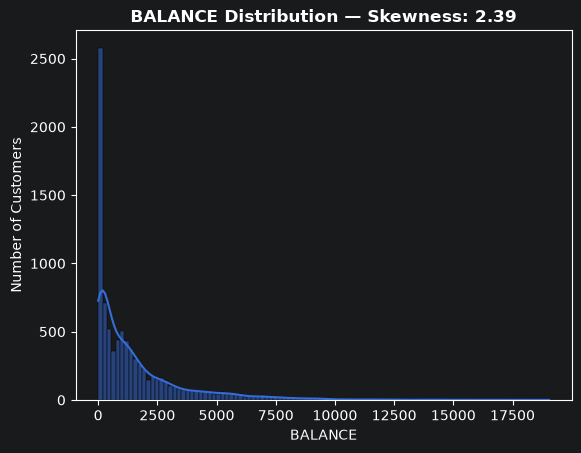

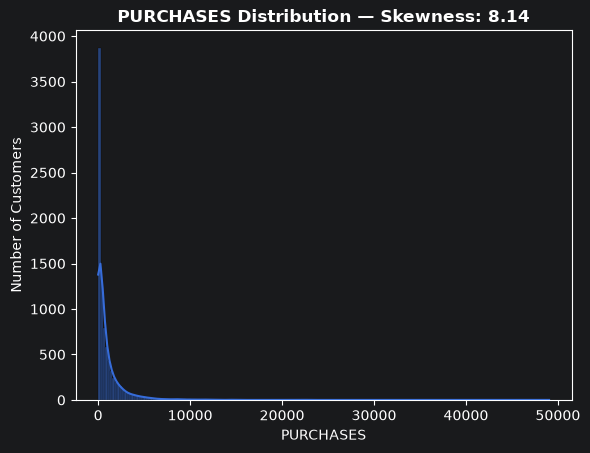

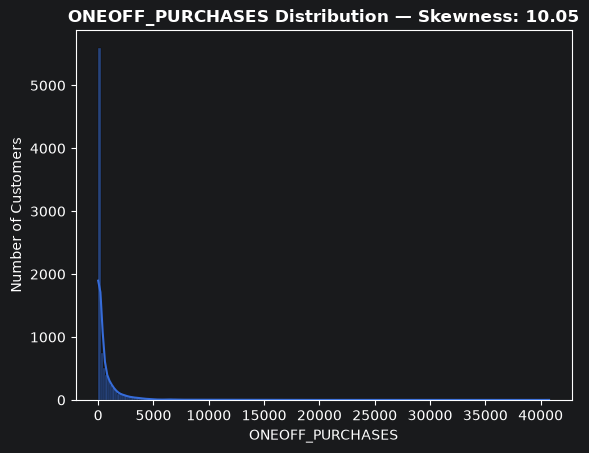

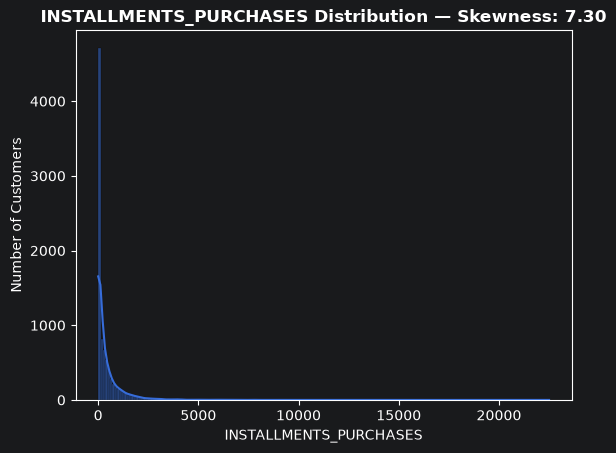

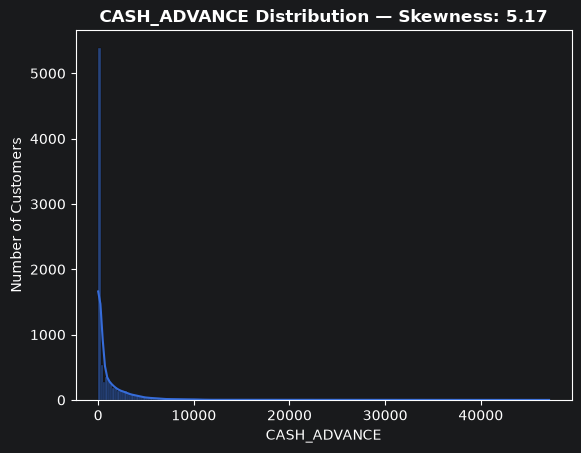

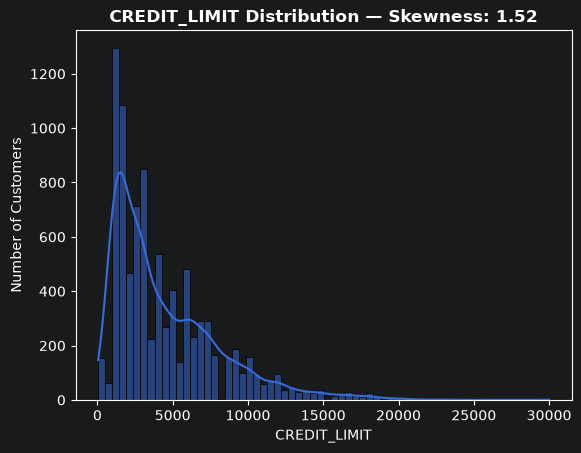

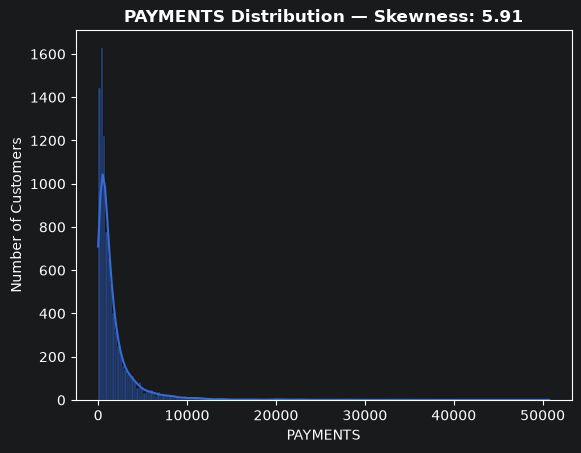

In [14]:
for column in COLUMNS[1:]: # the [1:] is for the first column that not numeric "CUST_ID"
    skewness = df[column].skew()

    sns.histplot(df[column], kde=True)

    plt.xlabel(column)
    plt.ylabel("Number of Customers")
    plt.title(
        f"{column} Distribution — Skewness: {skewness:.2f}",
        fontweight="bold"
    )

    plt.show()


## correlation heatmap

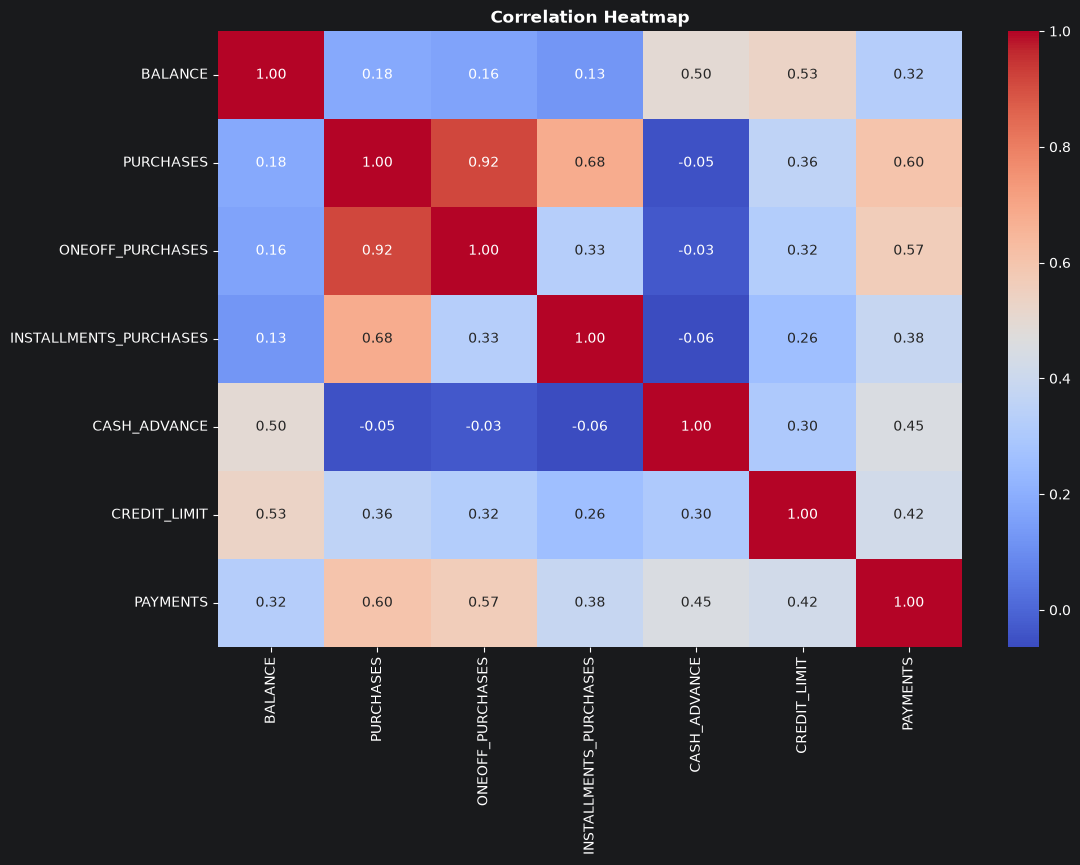

In [15]:
plt.figure(figsize=(12, 8))

correlation = df[COLUMNS[1:]].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap", fontweight="bold")
plt.show()

## boxplots per numeric variable with IQR

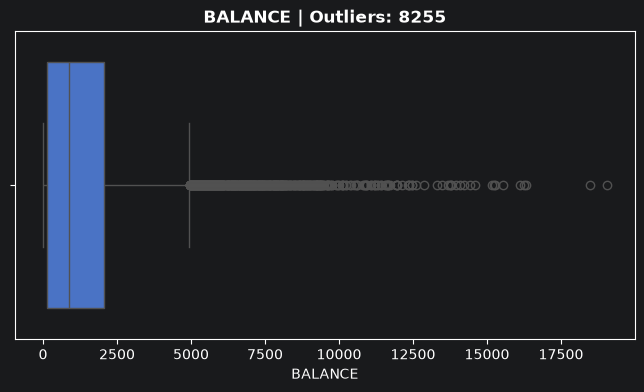

BALANCE
Q1: 128.28
Q3: 2054.14
IQR: 1925.86
Lower bound: -2760.51
Upper bound: 4942.93
Outliers: 8255
----------------------------------------


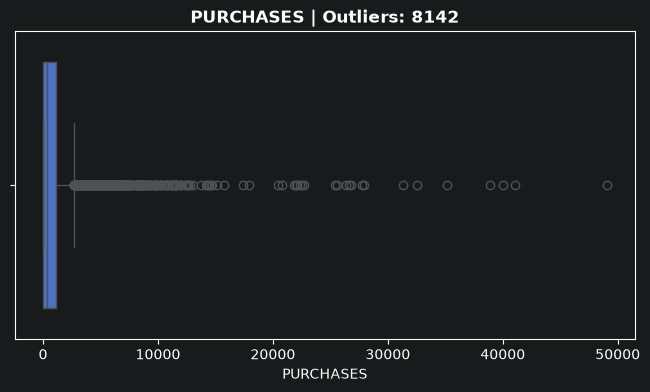

PURCHASES
Q1: 39.63
Q3: 1110.13
IQR: 1070.50
Lower bound: -1566.11
Upper bound: 2715.87
Outliers: 8142
----------------------------------------


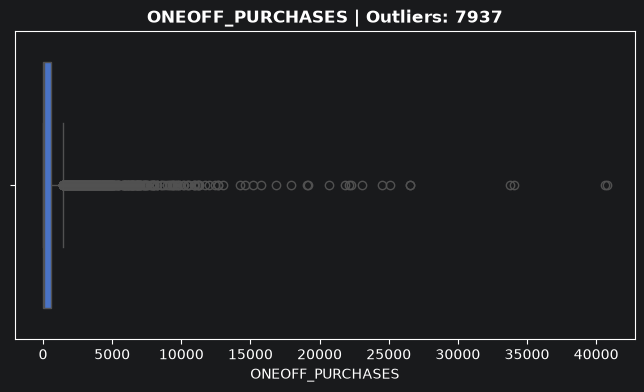

ONEOFF_PURCHASES
Q1: 0.00
Q3: 577.40
IQR: 577.40
Lower bound: -866.11
Upper bound: 1443.51
Outliers: 7937
----------------------------------------


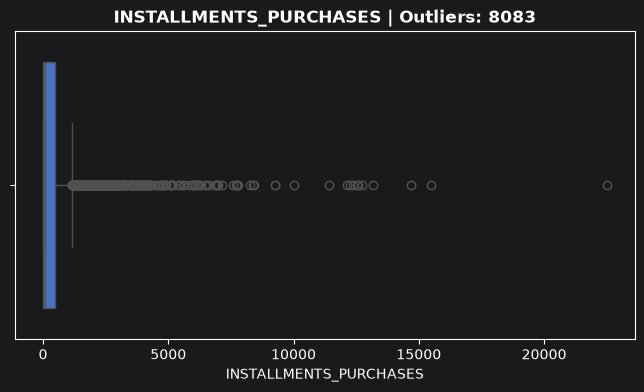

INSTALLMENTS_PURCHASES
Q1: 0.00
Q3: 468.64
IQR: 468.64
Lower bound: -702.96
Upper bound: 1171.59
Outliers: 8083
----------------------------------------


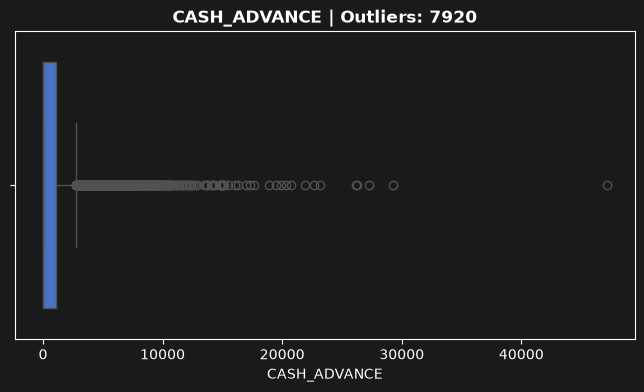

CASH_ADVANCE
Q1: 0.00
Q3: 1113.82
IQR: 1113.82
Lower bound: -1670.73
Upper bound: 2784.55
Outliers: 7920
----------------------------------------


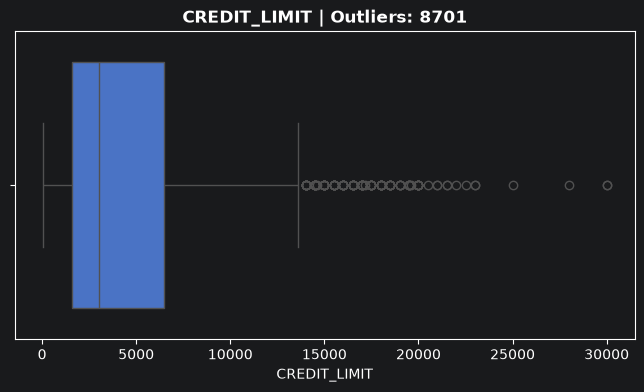

CREDIT_LIMIT
Q1: 1600.00
Q3: 6500.00
IQR: 4900.00
Lower bound: -5750.00
Upper bound: 13850.00
Outliers: 8701
----------------------------------------


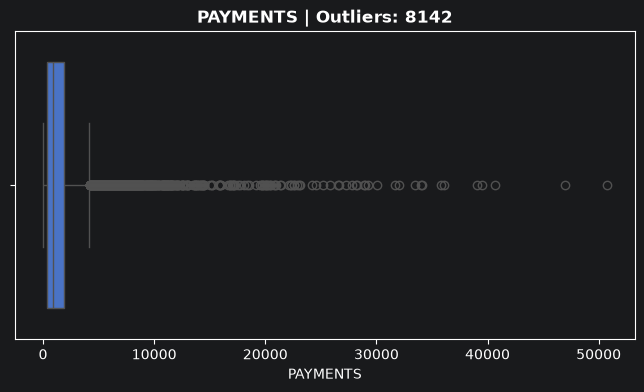

PAYMENTS
Q1: 383.28
Q3: 1901.13
IQR: 1517.86
Lower bound: -1893.51
Upper bound: 4177.92
Outliers: 8142
----------------------------------------


In [16]:
for column in COLUMNS[1:]:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] > lower_bound) & (df[column] < upper_bound)]

    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[column])

    plt.title(f"{column} | Outliers: {len(outliers)}", fontweight="bold")
    plt.xlabel(column)
    plt.show()

    print(f"{column}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Outliers: {len(outliers)}")
    print("-" * 40)

# EDA conclusions

## Dataset shape & quality
- 8,950 customers x 8 columns. `CUST_ID` is a unique string key, the other 7 are float64 monetary features.
- Data is essentially clean: **0 duplicate rows**, 8,950 unique IDs, and a single missing value in `CREDIT_LIMIT` (1 row).
- All features are non-negative, so no sign anomalies.

## Outliers (IQR method)
- Flagged counts are large (~7,900-8,700 per feature) but this is an artifact of right skew, not genuine data errors. For skewed spend features, IQR on the raw scale flags the normal mass of heavy spenders as outliers.
- Lower bounds are all negative, which is impossible given the data floor of 0, so only the upper bound matters.

## Data quality issue to fix
- 4,922 rows (55%) have `PAYMENTS > BALANCE`.
- 441 rows have `PURCHASES > CREDIT_LIMIT`.
